In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 7043
Columns: 21


In [2]:
# First look at the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# Check missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].dtype)
print("Missing values after conversion:", df["TotalCharges"].isnull().sum())

float64
Missing values after conversion: 11


In [6]:
df = df.dropna(subset=["TotalCharges"]).copy()

print("Rows after cleaning:", df.shape[0])
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Rows after cleaning: 7032
Missing TotalCharges: 0


In [7]:
df.to_csv("../data/cleaned_customer_churn.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [8]:
# Churn distribution
print(df["Churn"].value_counts())

print("\nChurn percentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


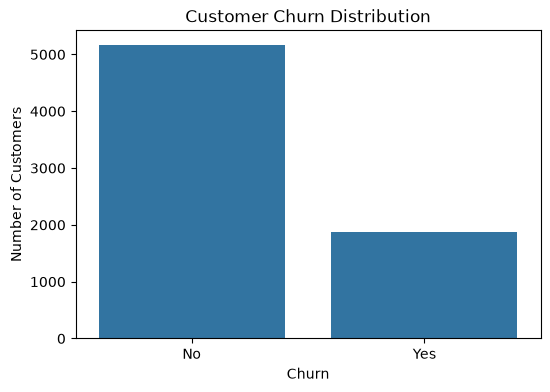

In [9]:
# Visualize churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [10]:
# Churn by gender
gender_churn = pd.crosstab(df["gender"], df["Churn"], normalize="index") * 100
print("Churn percentage by gender:")
print(gender_churn)

# Churn by senior citizen status
senior_churn = pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index") * 100
print("\nChurn percentage by senior citizen status:")
print(senior_churn)

Churn percentage by gender:
Churn          No        Yes
gender                      
Female  73.040482  26.959518
Male    73.795435  26.204565

Churn percentage by senior citizen status:
Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


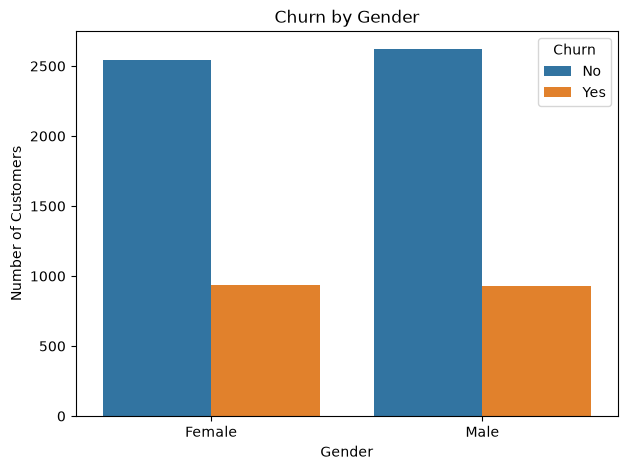

In [11]:
# Visualize churn by gender
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

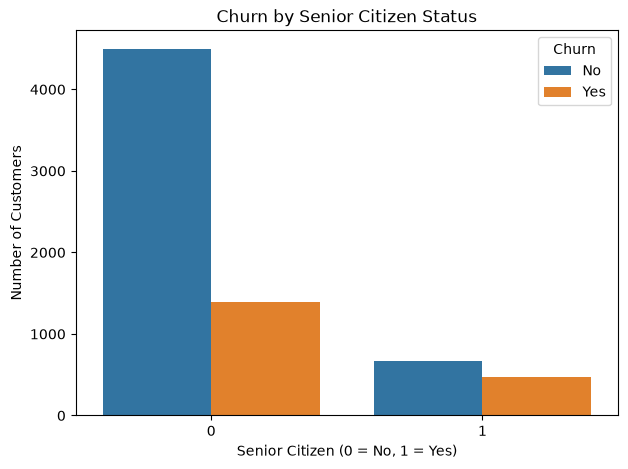

In [12]:
# Visualize churn by senior citizen status
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [13]:
# Compare tenure for churned and non-churned customers
print(df.groupby("Churn")["tenure"].describe())

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


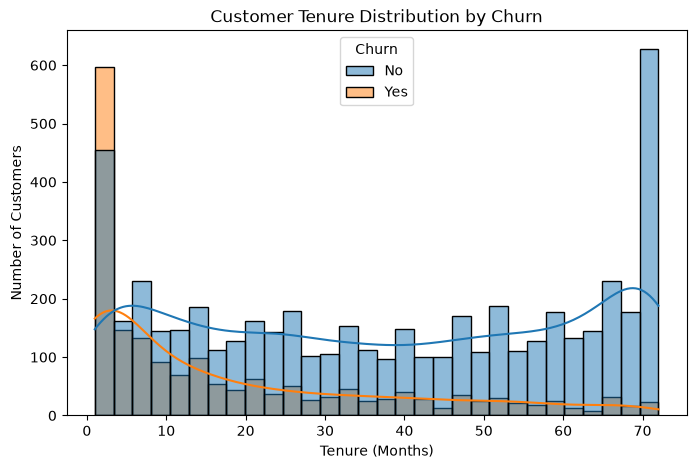

In [14]:
# Tenure distribution by churn
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Customer Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

In [15]:
# Average tenure by churn
print("Average tenure:")
print(df.groupby("Churn")["tenure"].mean())

Average tenure:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


In [16]:
# Churn by contract type
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by contract type:")
print(contract_churn)

Churn percentage by contract type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


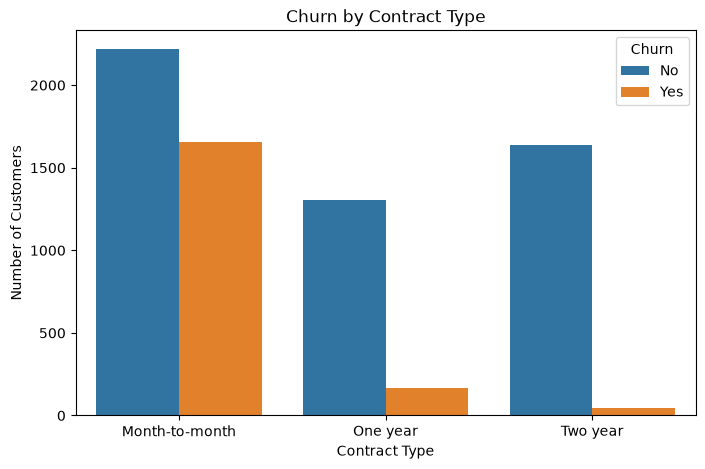

In [17]:
# Visualize churn by contract type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [18]:
# Monthly charges by churn
print(df.groupby("Churn")["MonthlyCharges"].describe())

        count       mean        std    min    25%    50%     75%     max
Churn                                                                   
No     5163.0  61.307408  31.094557  18.25  25.10  64.45  88.475  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.200  118.35


In [19]:
# Average monthly charges by churn
print("Average monthly charges:")
print(df.groupby("Churn")["MonthlyCharges"].mean())

Average monthly charges:
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


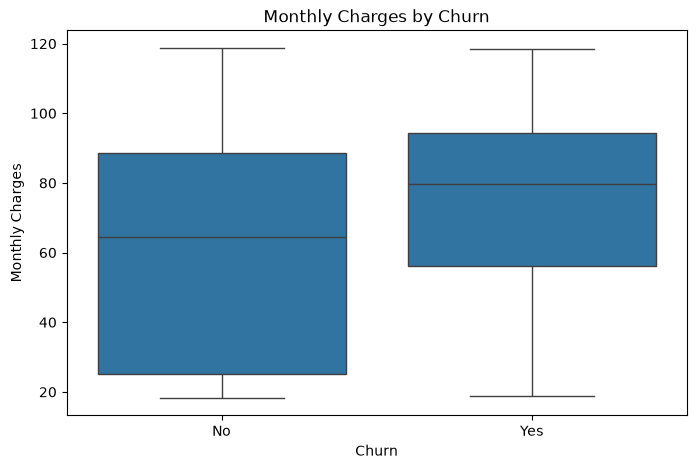

In [20]:
# Monthly charges distribution by churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [21]:
# Churn by payment method
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by payment method:")
print(payment_churn)

Churn percentage by payment method:
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


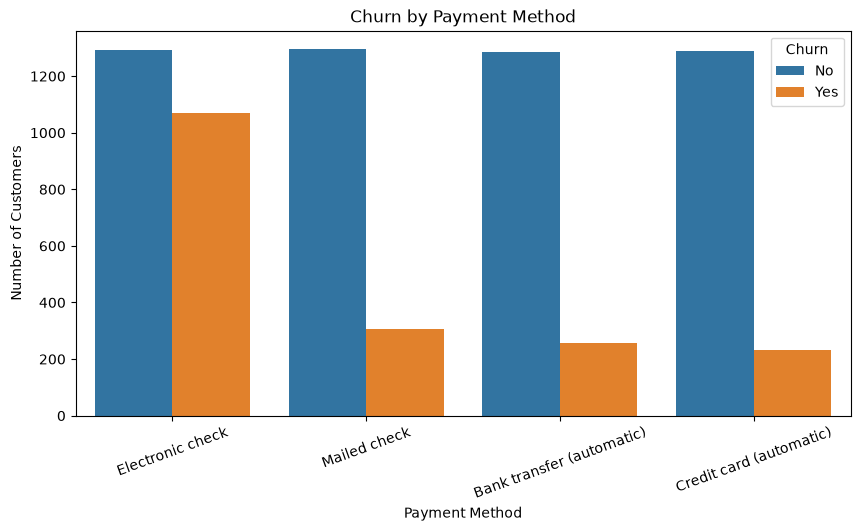

In [22]:
# Visualize churn by payment method
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

In [23]:
service_columns = [
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for column in service_columns:
    print(f"\n{column}")
    print(pd.crosstab(df[column], df["Churn"], normalize="index").round(2) * 100)


InternetService
Churn              No   Yes
InternetService            
DSL              81.0  19.0
Fiber optic      58.0  42.0
No               93.0   7.0

OnlineSecurity
Churn                  No   Yes
OnlineSecurity                 
No                   58.0  42.0
No internet service  93.0   7.0
Yes                  85.0  15.0

OnlineBackup
Churn                  No   Yes
OnlineBackup                   
No                   60.0  40.0
No internet service  93.0   7.0
Yes                  78.0  22.0

DeviceProtection
Churn                  No   Yes
DeviceProtection               
No                   61.0  39.0
No internet service  93.0   7.0
Yes                  77.0  23.0

TechSupport
Churn                  No   Yes
TechSupport                    
No                   58.0  42.0
No internet service  93.0   7.0
Yes                  85.0  15.0

StreamingTV
Churn                  No   Yes
StreamingTV                    
No                   66.0  34.0
No internet service  93.0   7.0
Y

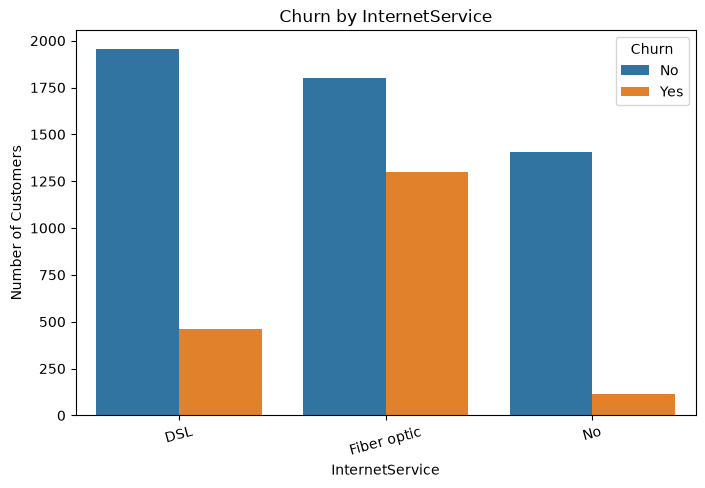

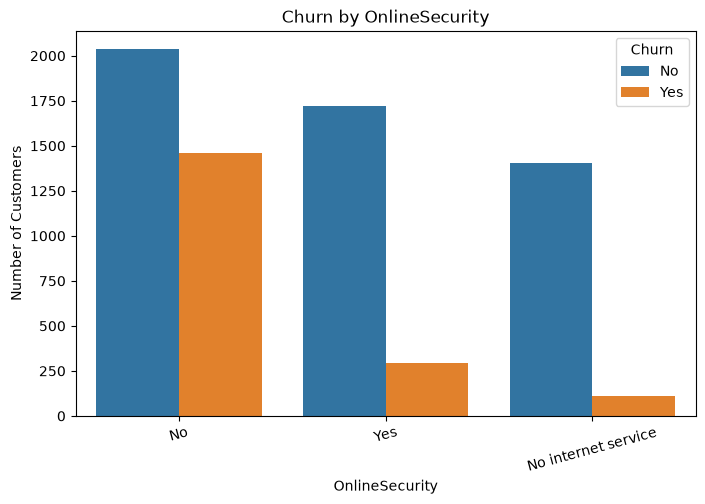

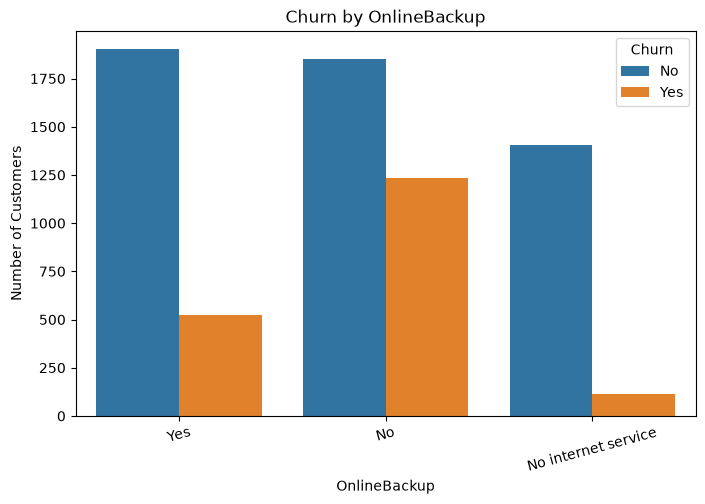

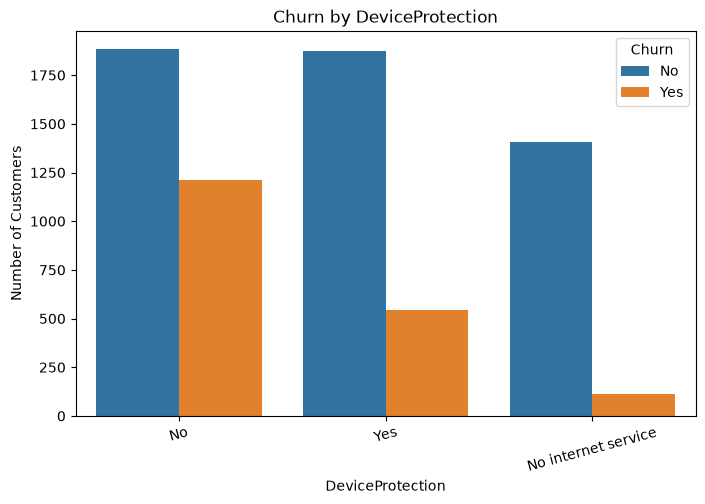

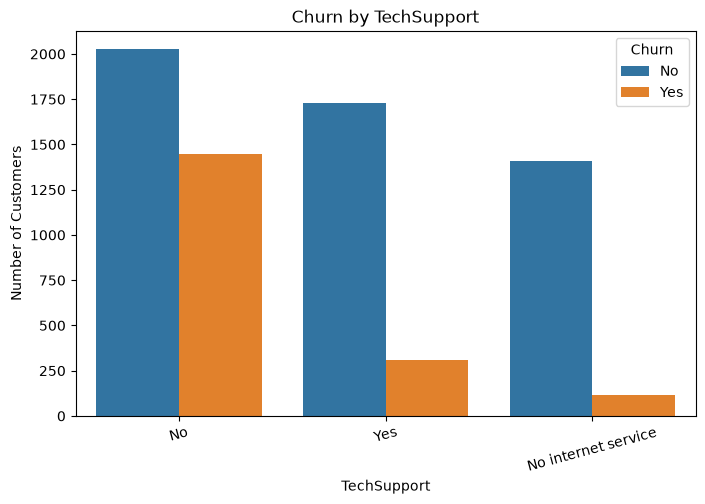

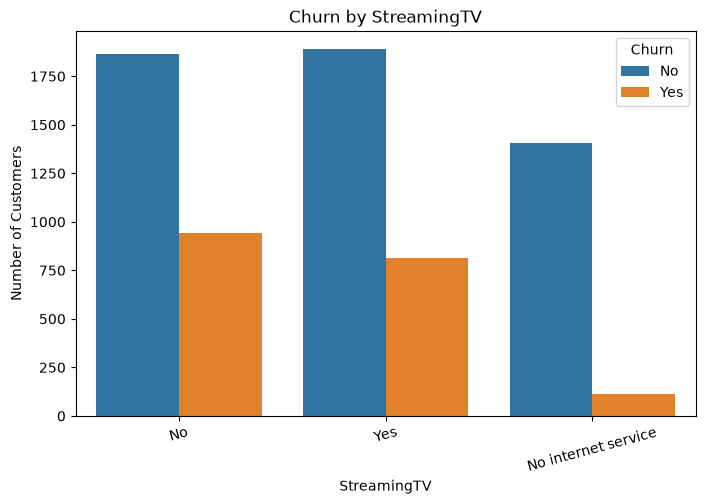

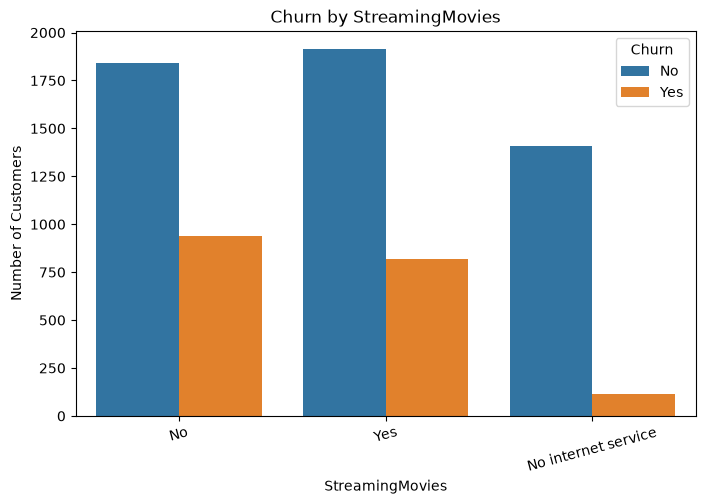

In [24]:
for column in service_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column, hue="Churn")
    plt.title(f"Churn by {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=15)
    plt.show()

In [25]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (7032, 20)
Target (y): (7032,)


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify text and numeric columns
categorical_columns = X.select_dtypes(include=["object"]).columns
numeric_columns = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:", len(categorical_columns))
print("Numeric columns:", len(numeric_columns))

Categorical columns: 16
Numeric columns: 4


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24116\3400440628.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(include=["object"]).columns


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 20)
Testing data: (1407, 20)


In [28]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training data shape:", X_train_encoded.shape)
print("Encoded testing data shape:", X_test_encoded.shape)

Encoded training data shape: (5625, 5670)
Encoded testing data shape: (1407, 5670)


In [29]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\Lenovo\Desktop\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
logistic_model = LogisticRegression(max_iter=3000)

logistic_model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\Lenovo\Desktop\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [31]:
logistic_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear"
)

logistic_model.fit(X_train_encoded, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [32]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = logistic_model.predict(X_test_encoded)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.56      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [33]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train_encoded, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [34]:
y_pred_tree = decision_tree.predict(X_test_encoded)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 0.7896233120113717

Classification Report:
              precision    recall  f1-score   support

          No       0.86      0.85      0.86      1033
         Yes       0.60      0.61      0.61       374

    accuracy                           0.79      1407
   macro avg       0.73      0.73      0.73      1407
weighted avg       0.79      0.79      0.79      1407



In [35]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

random_forest.fit(X_train_encoded, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [36]:
y_pred_rf = random_forest.predict(X_test_encoded)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7526652452025586

Classification Report:
              precision    recall  f1-score   support

          No       0.75      0.99      0.85      1033
         Yes       0.80      0.09      0.17       374

    accuracy                           0.75      1407
   macro avg       0.77      0.54      0.51      1407
weighted avg       0.76      0.75      0.67      1407



In [37]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train)

print("XGBoost model trained successfully!")

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1], got ['No' 'Yes']

In [38]:
y_train_xgb = y_train.map({"No": 0, "Yes": 1})
y_test_xgb = y_test.map({"No": 0, "Yes": 1})

print(y_train_xgb.unique())
print(y_test_xgb.unique())

[0 1]
[0 1]


In [39]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y_train_xgb)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [40]:
y_pred_xgb = xgb_model.predict(X_test_encoded)

print("XGBoost Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.7974413646055437

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



In [41]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_xgb, y_pred_xgb)
    ]
})

print(model_comparison)

                 Model  Accuracy
0  Logistic Regression  0.803838
1        Decision Tree  0.789623
2        Random Forest  0.752665
3              XGBoost  0.797441


In [42]:
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": logistic_model.coef_[0]
})

importance["Absolute_Importance"] = importance["Importance"].abs()

top_features = importance.sort_values(
    "Absolute_Importance",
    ascending=False
).head(15)

print(top_features[["Feature", "Importance"]])

                                           Feature  Importance
5659                        cat__Contract_Two year   -0.676961
5657                  cat__Contract_Month-to-month    0.592704
5636                      cat__InternetService_DSL   -0.347578
5637              cat__InternetService_Fiber optic    0.321710
5660                      cat__PaperlessBilling_No   -0.253291
5633                         cat__MultipleLines_No   -0.248783
5632                         cat__PhoneService_Yes   -0.210278
5641                       cat__OnlineSecurity_Yes   -0.205159
5650                          cat__TechSupport_Yes   -0.188765
5664           cat__PaymentMethod_Electronic check    0.188197
5630                           cat__Dependents_Yes   -0.181677
5639                        cat__OnlineSecurity_No    0.179291
5648                           cat__TechSupport_No    0.162897
5666                      remainder__SeniorCitizen    0.158000
5662  cat__PaymentMethod_Bank transfer (automatic)   -0

In [43]:
import joblib

joblib.dump(logistic_model, "../models/logistic_regression_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [44]:
model_comparison.to_csv("../models/model_comparison.csv", index=False)

print("Model comparison report saved successfully!")

Model comparison report saved successfully!


In [45]:
# Create tenure groups
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-36 months",
        "37-48 months",
        "49-60 months",
        "61-72 months"
    ]
)

print(df["TenureGroup"].value_counts().sort_index())

TenureGroup
0-12 months     2175
13-24 months    1024
25-36 months     832
37-48 months     762
49-60 months     832
61-72 months    1407
Name: count, dtype: int64


In [46]:
tenure_churn = pd.crosstab(
    df["TenureGroup"],
    df["Churn"],
    normalize="index"
) * 100

print("Churn percentage by tenure group:")
print(tenure_churn)

Churn percentage by tenure group:
Churn                No        Yes
TenureGroup                       
0-12 months   52.321839  47.678161
13-24 months  71.289062  28.710938
25-36 months  78.365385  21.634615
37-48 months  80.971129  19.028871
49-60 months  85.576923  14.423077
61-72 months  93.390192   6.609808


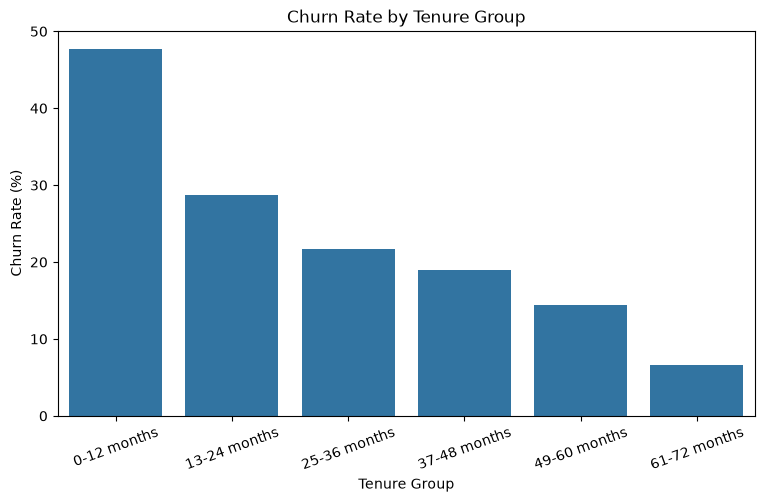

In [47]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_churn.reset_index(),
    x="TenureGroup",
    y="Yes"
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

In [48]:
service_columns = [
    "OnlineSecurity",
    "TechSupport",
    "OnlineBackup",
    "DeviceProtection"
]

for column in service_columns:
    print(f"\nChurn percentage by {column}:")
    result = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100
    print(result)


Churn percentage by OnlineSecurity:
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199

Churn percentage by TechSupport:
Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078

Churn percentage by OnlineBackup:
Churn                       No        Yes
OnlineBackup                             
No                   60.058309  39.941691
No internet service  92.565789   7.434211
Yes                  78.432990  21.567010

Churn percentage by DeviceProtection:
Churn                       No        Yes
DeviceProtection                         
No                   60.859729  39.140271
No internet service  92.565789   7.434211
Yes                  77.460711  22.539289


In [49]:
service_churn = {}

for column in service_columns:
    result = pd.crosstab(
        df[column],
        df["Churn"],
        normalize="index"
    ) * 100
    
    service_churn[column] = result["Yes"]["No"]

service_churn_df = pd.DataFrame(
    list(service_churn.items()),
    columns=["Service", "Churn Rate"]
)

print(service_churn_df)

            Service  Churn Rate
0    OnlineSecurity   41.778667
1       TechSupport   41.647465
2      OnlineBackup   39.941691
3  DeviceProtection   39.140271


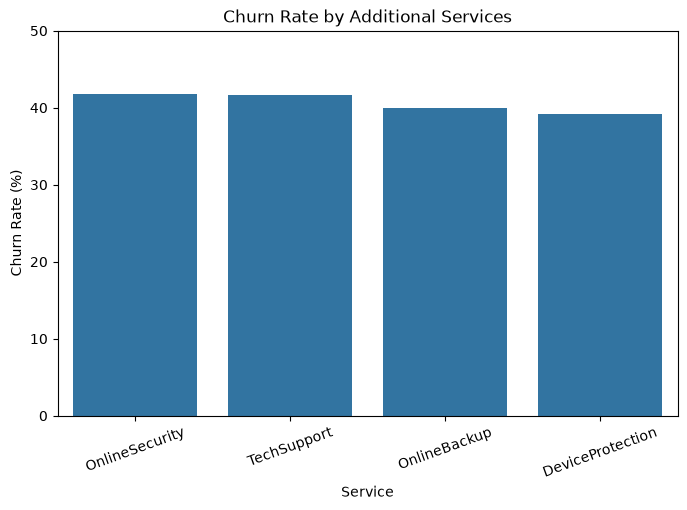

In [50]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=service_churn_df,
    x="Service",
    y="Churn Rate"
)

plt.title("Churn Rate by Additional Services")
plt.xlabel("Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.ylim(0, 50)
plt.show()

In [51]:
# Create a copy for machine learning
ml_df = df.copy()

# Remove customer ID because it does not help predict churn
ml_df = ml_df.drop("customerID", axis=1)

print("ML dataset shape:", ml_df.shape)
print("\nColumns:")
print(ml_df.columns.tolist())

ML dataset shape: (7032, 21)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TenureGroup']


In [52]:
# Separate features and target
X = ml_df.drop("Churn", axis=1)
y = ml_df["Churn"]

# Convert categorical columns into numeric columns
X = pd.get_dummies(X, drop_first=True)

# Convert churn target into 0 and 1
y = y.map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features shape: (7032, 35)
Target shape: (7032,)

Target values:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (5625, 35)
Testing features: (1407, 35)
Training target: (5625,)
Testing target: (1407,)


In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create and train Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Evaluate the model
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))

Logistic Regression Results
Accuracy: 0.7924662402274343
Precision: 0.632258064516129
Recall: 0.5240641711229946
F1 Score: 0.5730994152046783


c:\Users\Lenovo\Desktop\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

# Select the 15 most important features based on ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=15)

selector.fit(X_train, y_train)

selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
for feature in selected_features:
    print(feature)

Selected Features:
tenure
MonthlyCharges
TotalCharges
InternetService_Fiber optic
InternetService_No
OnlineSecurity_No internet service
OnlineBackup_No internet service
DeviceProtection_No internet service
TechSupport_No internet service
StreamingTV_No internet service
StreamingMovies_No internet service
Contract_Two year
PaperlessBilling_Yes
PaymentMethod_Electronic check
TenureGroup_61-72 months


In [56]:
selected_features_df = pd.DataFrame({
    "Selected Feature": selected_features
})

selected_features_df.to_csv(
    "../models/selected_features.csv",
    index=False
)

print("Selected features saved successfully.")

Selected features saved successfully.
